# Clustering Students

**Import libraries**

In [1]:
# for basic mathematics operation 
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as sch

# for visualizations
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

**Costants**

In [2]:
class Columns:
  College_ID = "College_ID"
  IQ = "IQ"
  CGPA = "CGPA"
  Prev_Sem_Result = "Prev_Sem_Result"
  Academic_Performance = "Academic_Performance"
  Internship_Experience = "Internship_Experience"
  Extra_Curricular_Score = "Extra_Curricular_Score"
  Communication_Skills = "Communication_Skills"
  Projects_Completed = "Projects_Completed"
  Placement = "Placement"
  Result_mean = "Result_mean"

**Reaading dataset**

In [3]:
df = pd.read_csv('../data/processed/college_student_placement_clean.csv')
df.head()

,College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,CLG0030,107,6.61,6.28,8,0,8,8,4,0
1,CLG0061,97,5.52,5.37,8,0,7,8,0,0
2,CLG0036,109,5.36,5.83,9,0,3,1,1,0
3,CLG0055,122,5.47,5.75,6,1,1,6,1,0
4,CLG0004,96,7.91,7.69,7,0,8,10,2,0


In [4]:
# 1. Inizializzare lo scaler
scaler = StandardScaler()
# df[Columns.Result_mean] = (df[Columns.CGPA] + df[Columns.Prev_Sem_Result]) / 2
# 2. Selezionare le colonne da standardizzare (tutte le colonne numeriche)
columns_to_scale = [Columns.IQ,Columns.CGPA,Columns.Prev_Sem_Result, Columns.Academic_Performance, Columns.Internship_Experience, Columns.Extra_Curricular_Score, Columns.Communication_Skills, Columns.Projects_Completed]
data_to_scale = df[columns_to_scale]

# 3. Calcolare i parametri e trasformare i dati in un solo passaggio
scaled_features = scaler.fit_transform(data_to_scale)

# 4. Riconvertire in un DataFrame e nominare le colonne
df_scaled = pd.DataFrame(scaled_features, columns=columns_to_scale)

# 5. Aggiunta della colonna "Placement"
df_scaled['Placement'] = df['Placement']

print("\nDataFrame Standardizzato (Z-Score):")
df_scaled.head()


DataFrame Standardizzato (Z-Score):


,IQ,CGPA,Prev_Sem_Result,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,0.500135,-0.851919,-0.639521,0.853921,-0.810387,0.958593,0.840550,0.866381,0
1,-0.164214,-1.470939,-1.392572,0.853921,-0.810387,0.642131,0.840550,-1.464794,0
2,0.633004,-1.158028,-1.503111,1.201949,-0.810387,-0.623713,-1.572644,-0.882000,0
3,1.496657,-1.212447,-1.427115,0.157865,1.233979,-1.256636,0.151066,-0.882000,0
4,-0.230648,0.107220,0.258612,0.505893,-0.810387,0.958593,1.530034,-0.299206,0


In [5]:
df_scaled.describe()

,IQ,CGPA,Prev_Sem_Result,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
count,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,10000.000000
mean,-1.197265e-16,1.890044e-16,5.691447e-16,-6.536993e-17,1.328715e-16,-9.237056e-17,3.943512e-17,1.016076e-16,0.165900
std,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,0.372009
min,-3.884563e+00,-2.035539e+00,-1.751825e+00,-1.582274e+00,-8.103865e-01,-1.573097e+00,-1.572644e+00,-1.464794e+00,0.000000
25%,-6.956921e-01,-8.451170e-01,-8.606004e-01,-8.862180e-01,-8.103865e-01,-9.401746e-01,-8.831598e-01,-8.820000e-01,0.000000
50%,-3.134395e-02,1.198652e-02,1.680684e-02,1.578654e-01,-8.103865e-01,9.209021e-03,1.510659e-01,2.835874e-01,0.000000
75%,6.994390e-01,8.418804e-01,8.665792e-01,8.539210e-01,1.233979e+00,9.585926e-01,8.405497e-01,8.663811e-01,0.000000
max,3.888310e+00,1.991488e+00,1.702534e+00,1.549977e+00,1.233979e+00,1.591515e+00,1.530034e+00,1.449175e+00,1.000000


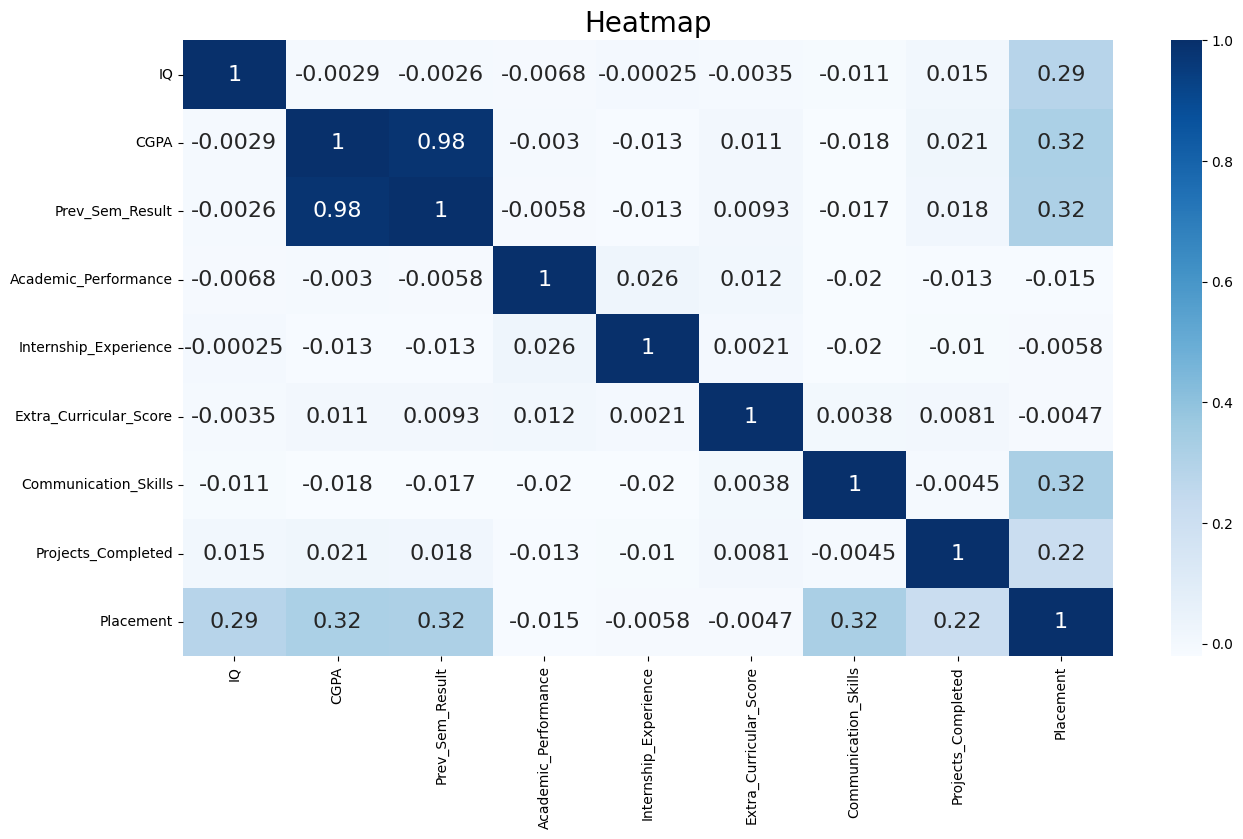

In [6]:
plt.figure(figsize=(15,8))
sns.heatmap(df_scaled.corr(), cmap = 'Blues', annot = True, annot_kws={"fontsize": 16})
plt.title('Heatmap', fontsize = 20)
plt.show()

### Analisi heatmap
1. Forte Multicollinearità (Ridondanza)
L'aspetto più evidente è la correlazione quasi perfetta (0.98) tra CGPA (Media dei voti) e Prev_Sem_Result (Risultato semestre precedente).
Signiche che le due variabili portano quasi la stessa informazione. In molti modelli di machine learning, avere variabili così correlate può creare multicollinearità o semplicemente essere ridondante.
Per il clustering o modelli futuri tenerne solo una (probabilmente CGPA è più rappresentativa) o di combinarle, per evitare di dare troppo "peso" al rendimento scolastico puro rispetto ad altre caratteristiche.

2. Correlazioni con il Target (Placement)
Nell'ultima riga o colonna relativa a Placement si evidenziano quali fattori influenzano di più l'assunzione lineare:
Le correlazioni più alte sono con CGPA (0.32), Prev_Sem_Result (0.32) e Communication_Skills (0.32). Anche il IQ ha un discreto impatto positivo (0.29).
I fattori deboli sono, Internship_Experience e Extra_Curricular_Score che mostrano correlazioni vicine allo zero con il Placement in questo dataset. Questo suggerisce che, almeno linearmente, non sembrano essere fattori determinanti per l'assunzione in questi dati specifici.

3. L'anomalia di Academic_Performance
C'è un dato molto strano: la variabile Academic_Performance ha correlazioni quasi nulle con tutto, persino con CGPA (-0.003).
Normalmente ci si aspetterebbe che la "Performance Accademica" sia legata ai voti (CGPA). Il fatto che sia totalmente scorrelata suggerisce che questa colonna misuri qualcosa di completamente diverso (es. condotta, frequenza) o che i dati in essa contenuti non siano coerenti con le altre metriche di rendimento. Potrebbe essere "rumore" nel dataset.

In [7]:
df_scaled = df_scaled.drop(Columns.Prev_Sem_Result, axis=1)
df_scaled.head()

,IQ,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,0.500135,-0.851919,0.853921,-0.810387,0.958593,0.840550,0.866381,0
1,-0.164214,-1.470939,0.853921,-0.810387,0.642131,0.840550,-1.464794,0
2,0.633004,-1.158028,1.201949,-0.810387,-0.623713,-1.572644,-0.882000,0
3,1.496657,-1.212447,0.157865,1.233979,-1.256636,0.151066,-0.882000,0
4,-0.230648,0.107220,0.505893,-0.810387,0.958593,1.530034,-0.299206,0


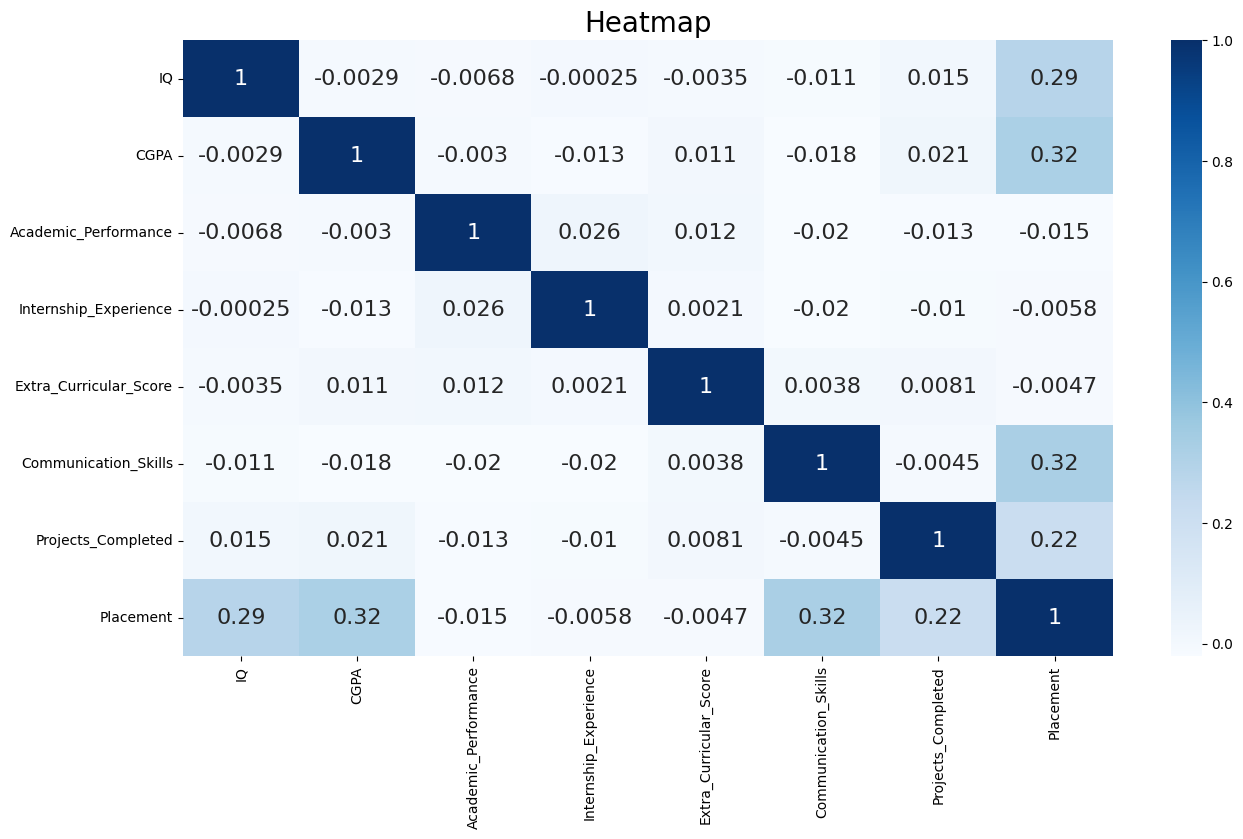

In [8]:
plt.figure(figsize=(15,8))
sns.heatmap(df_scaled.corr(), cmap = 'Blues', annot = True, annot_kws={"fontsize": 16})
plt.title('Heatmap', fontsize = 20)
plt.show()

## Kmeans Algorithm

**Ricerca del numero ottimale di cluster**
L'elbow method ci permette di trovare il numero ottimale di cluster.
WCSS (Within Cluster Sum of Squares) è la somma dei quadrati dei residui all'interno di ogni cluster.

In [9]:
features_to_use = [
    Columns.IQ,
    Columns.CGPA, 
    # Columns.Academic_Performance, # Excluded due to lack of correlation/clarity
    # Columns.Internship_Experience,
    # Columns.Extra_Curricular_Score,
    Columns.Communication_Skills,
    Columns.Projects_Completed,
    Columns.Placement
]
df_high_correlation = df_scaled[features_to_use]

df_high_correlation.head()

,IQ,CGPA,Communication_Skills,Projects_Completed,Placement
0,0.500135,-0.851919,0.840550,0.866381,0
1,-0.164214,-1.470939,0.840550,-1.464794,0
2,0.633004,-1.158028,-1.572644,-0.882000,0
3,1.496657,-1.212447,0.151066,-0.882000,0
4,-0.230648,0.107220,1.530034,-0.299206,0


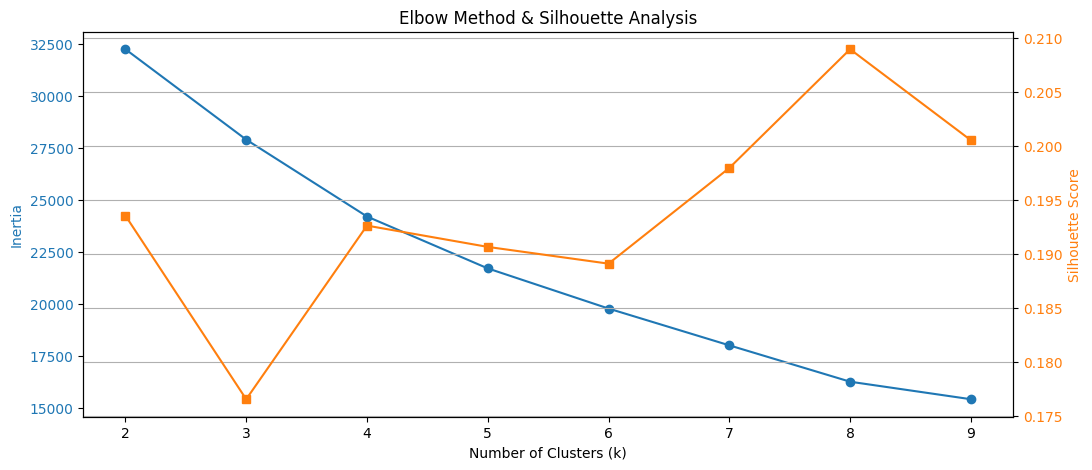

In [10]:
inertia = []
silhouette_scores = []
K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_high_correlation.drop(Columns.Placement, axis=1))
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(df_high_correlation.drop(Columns.Placement, axis=1), kmeans.labels_))

fig, ax1 = plt.subplots(figsize=(12, 5))

# Elbow Curve
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia', color='tab:blue')
ax1.plot(K_range, inertia, color='tab:blue', marker='o', label='Inertia')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Silhouette Score
ax2 = ax1.twinx()
ax2.set_ylabel('Silhouette Score', color='tab:orange')
ax2.plot(K_range, silhouette_scores, color='tab:orange', marker='s', label='Silhouette')
ax2.tick_params(axis='y', labelcolor='tab:orange')

plt.title('Elbow Method & Silhouette Analysis')
plt.grid(True)
plt.show()

**PCA visualization**

Riduzione a due dimensioni con PCA e visualizzazione con matplotlib.

[1 0 0 ... 1 0 1]


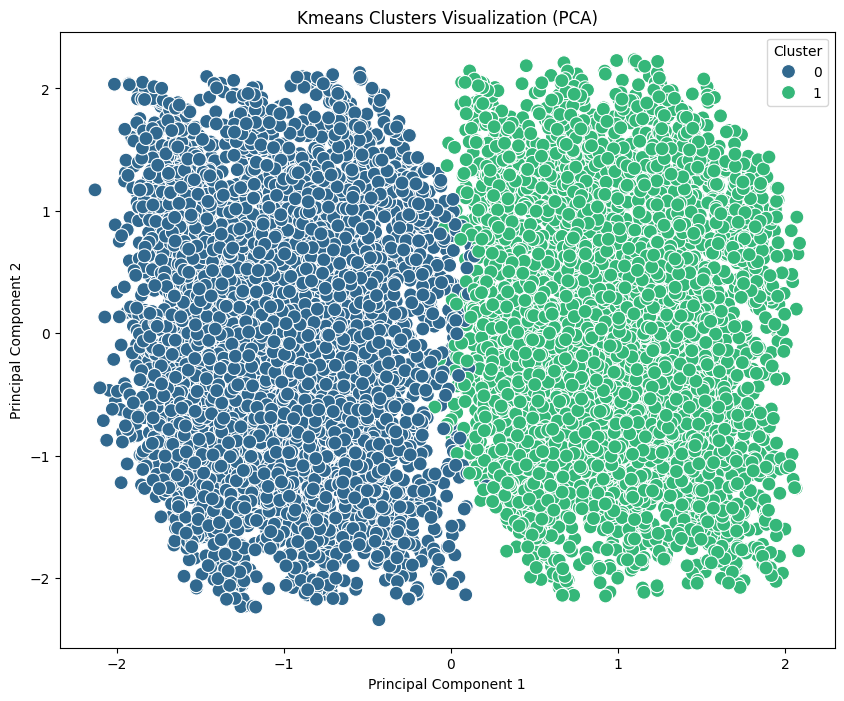

In [17]:
km = KMeans(n_clusters = 2, init = 'k-means++', max_iter = 300, n_init = 10, random_state = 0)
y_means = km.fit_predict(df_high_correlation.drop(Columns.Placement, axis=1))
print(y_means)

# Aggiungi l'etichetta del cluster al tuo DataFrame originale per poter colorare i punti
df_high_correlation['Cluster'] = y_means

df_high_correlation.head()

pca = PCA(n_components=2)
X_pca = pca.fit_transform(df_high_correlation)

plt.figure(figsize=(10, 8))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df_high_correlation['Cluster'], palette='viridis', s=100)
plt.title('Kmeans Clusters Visualization (PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()

**Cluster Profiling**

               IQ      CGPA  Communication_Skills  Projects_Completed  \
Cluster                                                                 
0       -0.005827 -0.027217              0.003003           -0.882819   
1        0.005776  0.026978             -0.002976            0.875085   

         Placement  
Cluster             
0         0.097429  
1         0.233771  


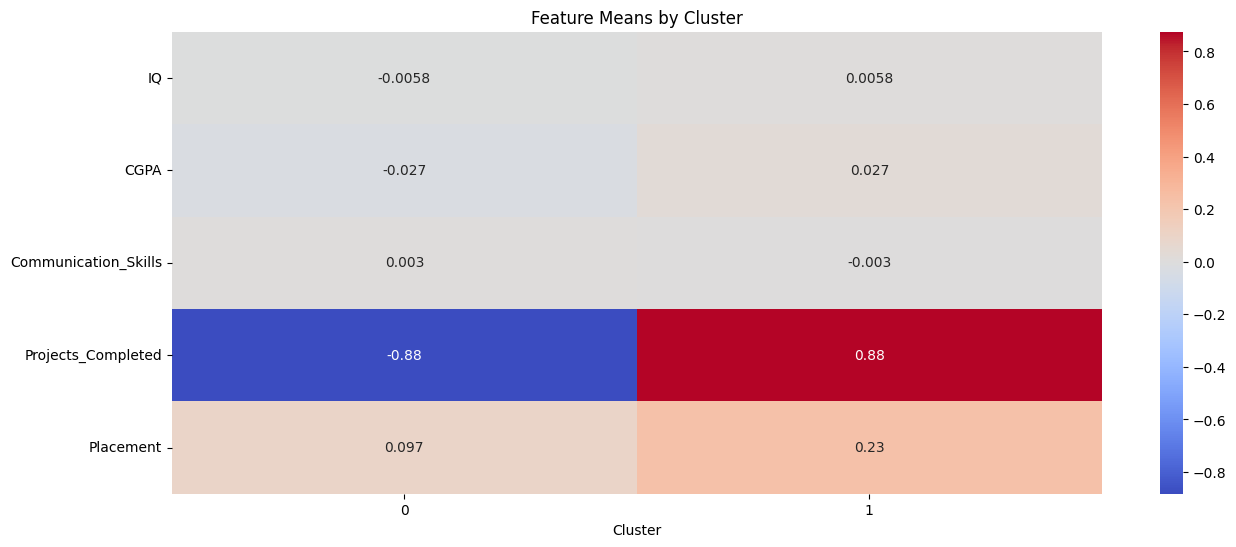

In [18]:
cluster_means = df_high_correlation.groupby('Cluster').mean(numeric_only=True)
print(cluster_means)

# Visualizing the profile
plt.figure(figsize=(15, 6))
sns.heatmap(cluster_means.T, annot=True, cmap='coolwarm')
plt.title('Feature Means by Cluster')
plt.show()

**Placement Rate**

Cluster
0    0.097429
1    0.233771
Name: Placement, dtype: float64


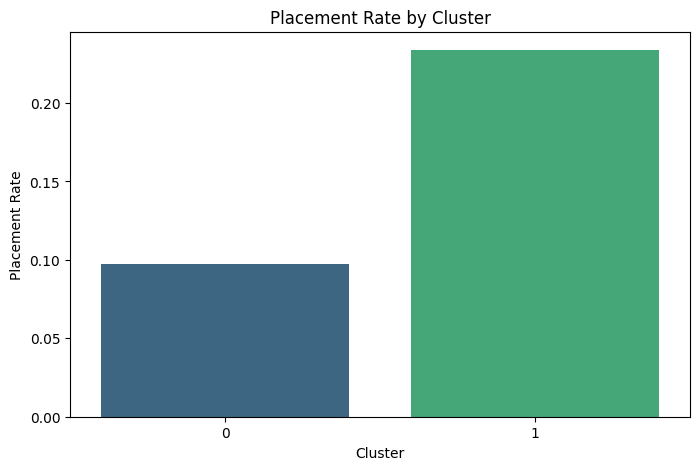

In [19]:
placement_rate = df_high_correlation.groupby('Cluster')['Placement'].mean()
print(placement_rate)

plt.figure(figsize=(8, 5))
sns.barplot(x=placement_rate.index, y=placement_rate.values, palette='viridis')
plt.title('Placement Rate by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Placement Rate')
plt.show()

### DBSCAN

In [20]:
df_high_correlation.head()

,IQ,CGPA,Communication_Skills,Projects_Completed,Placement,Cluster
0,0.500135,-0.851919,0.840550,0.866381,0,1
1,-0.164214,-1.470939,0.840550,-1.464794,0,0
2,0.633004,-1.158028,-1.572644,-0.882000,0,0
3,1.496657,-1.212447,0.151066,-0.882000,0,0
4,-0.230648,0.107220,1.530034,-0.299206,0,0


In [21]:
# Initialize DBSCAN
# eps: The maximum distance between two samples for one to be considered as in the neighborhood of the other.
# min_samples: The number of samples (or total weight) in a neighborhood for a point to be considered as a core point.
dbscan = DBSCAN(eps=2, min_samples=5)

# Fit DBSCAN
clusters_dbscan = dbscan.fit_predict(df_scaled)

# Add cluster labels to dataframe
df_scaled['Cluster_DBSCAN'] = clusters_dbscan

# Check value counts (Label -1 means noise/outlier)
print(df_scaled['Cluster_DBSCAN'].value_counts())

df_scaled = df_scaled.drop(Columns.Placement, axis=1)

df_scaled.head()

Cluster_DBSCAN
 0    6036
 1    3962
-1       2
Name: count, dtype: int64


,IQ,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Cluster_DBSCAN
0,0.500135,-0.851919,0.853921,-0.810387,0.958593,0.840550,0.866381,0
1,-0.164214,-1.470939,0.853921,-0.810387,0.642131,0.840550,-1.464794,0
2,0.633004,-1.158028,1.201949,-0.810387,-0.623713,-1.572644,-0.882000,0
3,1.496657,-1.212447,0.157865,1.233979,-1.256636,0.151066,-0.882000,1
4,-0.230648,0.107220,0.505893,-0.810387,0.958593,1.530034,-0.299206,0


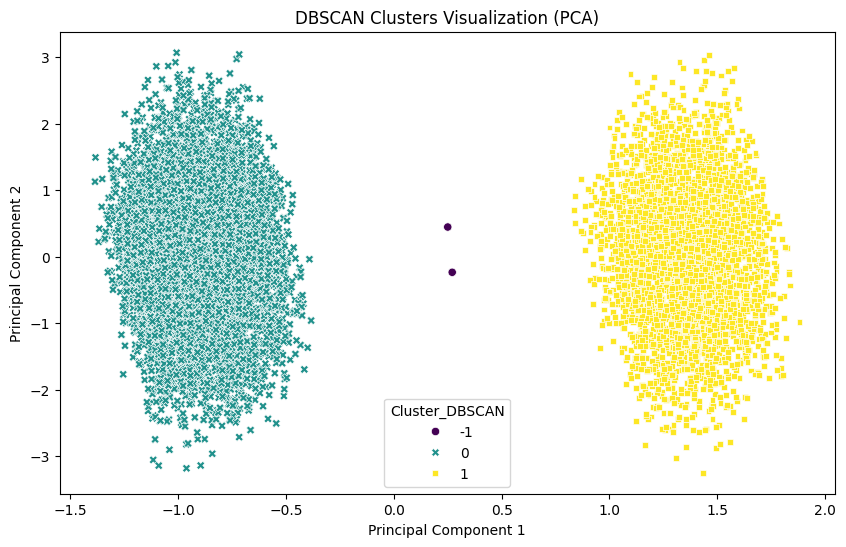

In [22]:
pca_dbscan = PCA(n_components=2)
dbscan_pca = pca_dbscan.fit_transform(df_scaled)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=dbscan_pca[:, 0], y=dbscan_pca[:, 1], hue=df_scaled['Cluster_DBSCAN'], palette='viridis', style=df_scaled['Cluster_DBSCAN'])
plt.title('DBSCAN Clusters Visualization (PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

**Hierarchical clustering**

In [324]:
df_high_correlation.head()

,IQ,CGPA,Communication_Skills,Projects_Completed,Placement,Cluster
0,0.500135,-0.851919,0.840550,0.866381,0,1
1,-0.164214,-1.470939,0.840550,-1.464794,0,0
2,0.633004,-1.158028,-1.572644,-0.882000,0,0
3,1.496657,-1.212447,0.151066,-0.882000,0,0
4,-0.230648,0.107220,1.530034,-0.299206,0,0


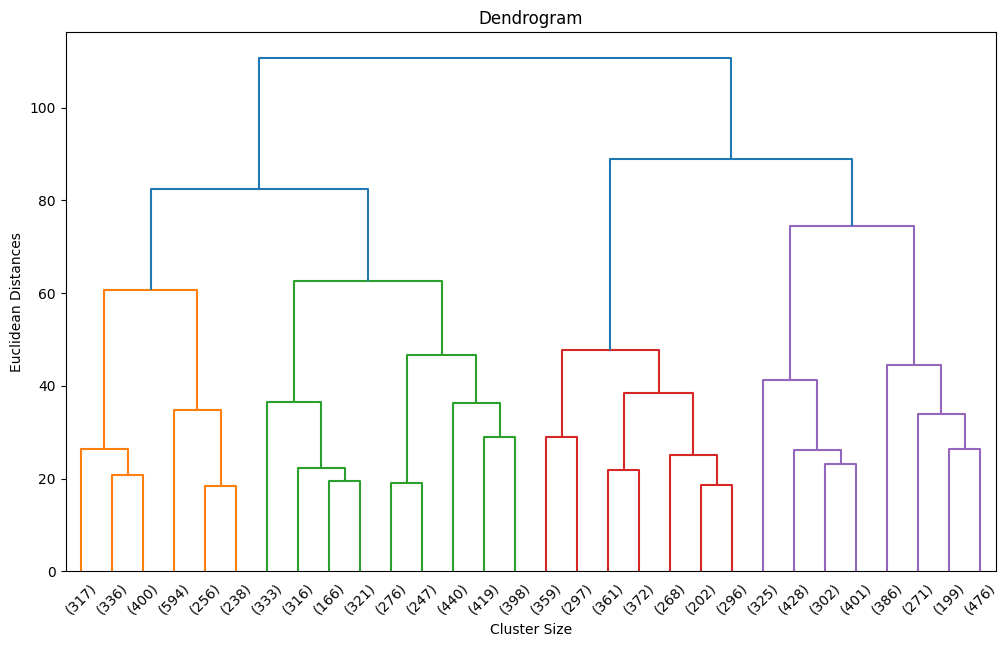

In [325]:
# Plot Dendrogram to determine optimal number of clusters
df_high_correlation = df_high_correlation.drop(columns=['Cluster'])

plt.figure(figsize=(12, 7))
plt.title("Dendrogram")
# To keep the plot readable, we might limit the number of leaf nodes shown if the dataset is huge,
# but for ~3000 rows, it might be dense. Let's truncate for clarity if needed.
dendrogram = sch.dendrogram(sch.linkage(df_high_correlation, method='ward'), truncate_mode='lastp', p=30)
plt.xlabel("Cluster Size")
plt.ylabel("Euclidean Distances")
plt.show()

In [326]:
# Fit Agglomerative Clustering
# Based on Dendrogram or previous K-Means, let's try 3 clusters again for comparison
hc = AgglomerativeClustering(n_clusters=4, metric='euclidean', linkage='ward')
clusters_hc = hc.fit_predict(df_high_correlation)

# Add cluster labels to dataframe
df_high_correlation['Cluster_HC'] = clusters_hc
df_high_correlation['Cluster_HC'].value_counts()

Cluster_HC
1    2916
0    2788
2    2155
3    2141
Name: count, dtype: int64

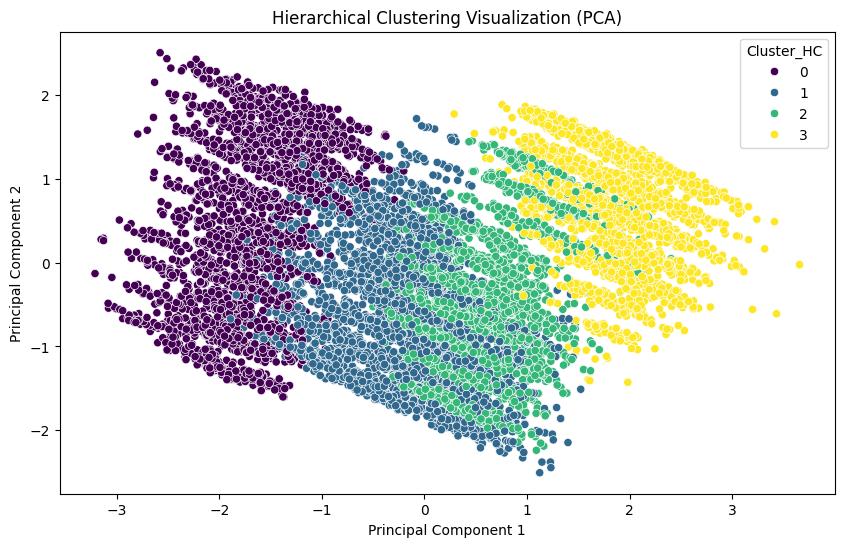

In [327]:
X_pca = pca.fit_transform(df_high_correlation)

# Visualize Hierarchical Clusters using PCA
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df_high_correlation['Cluster_HC'], palette='viridis')
plt.title('Hierarchical Clustering Visualization (PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()